In [1]:
import requests
import pandas as pd

url = 'https://data.lacity.org/resource/5m3t-xjex.json?$select=ZIP_code,CD,permit_sub_type,permit_nbr,issue_date&$where=permit_type=%27HVAC%27&$limit=150000'

resp = requests.get(url)
data_frame =pd.DataFrame(resp.json())
data_frame.shape

(148630, 5)

In [2]:
data_frame.head()

,ZIP_code,CD,permit_sub_type,permit_nbr,issue_date
0,90062,8,1 or 2 Family Dwelling,12044-90000-03392,2012-04-03T00:00:00.000
1,91344,12,1 or 2 Family Dwelling,19044-90000-15375,2019-12-16T00:00:00.000
2,90024,5,Apartment,18044-70000-04814,2018-04-24T00:00:00.000
3,90028,13,Commercial,12044-10000-10870,2012-10-10T00:00:00.000
4,90004,4,1 or 2 Family Dwelling,15044-90000-08741,2015-08-25T00:00:00.000


In [3]:
data_frame.dtypes

ZIP_code           str
CD                 str
permit_sub_type    str
permit_nbr         str
issue_date         str
dtype: object

In [4]:
data_frame['issue_date'] = pd.to_datetime(data_frame['issue_date'])
data_frame.dtypes

ZIP_code                      str
CD                            str
permit_sub_type               str
permit_nbr                    str
issue_date         datetime64[us]
dtype: object

In [5]:
data_frame['issue_date'].min(), data_frame['issue_date'].max()

(Timestamp('2010-01-03 00:00:00'), Timestamp('2019-12-31 00:00:00'))

In [6]:
data_frame.isnull().sum()

ZIP_code            13
CD                 113
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [7]:
data_frame.isna().sum()

ZIP_code            13
CD                 113
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [8]:
data_frame['permit_nbr'].duplicated().sum()

np.int64(0)

In [9]:
import requests
import pandas as pd

url = 'https://data.lacity.org/resource/67is-svtd.json?$select=ZIP_code,CD,permit_sub_type,permit_nbr,issue_date&$where=permit_type=%27HVAC%27&$limit=100000'
response = requests.get(url)
df = pd.DataFrame(response.json())
df.shape

(91926, 5)

In [10]:
df['issue_date'] = pd.to_datetime(df['issue_date'])

In [11]:
df['issue_date'].min(), df['issue_date'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2026-09-05 00:00:00'))

In [12]:
df.isnull().sum()

ZIP_code             2
CD                 337
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [13]:
df['permit_nbr'].duplicated().sum()

np.int64(0)

In [14]:
df.head()

,ZIP_code,CD,permit_sub_type,permit_nbr,issue_date
0,90002,8,1 or 2 Family Dwelling,25044-90000-10100,2025-09-04
1,91403,4,Commercial,23044-90000-22103,2023-09-12
2,90016,10,1 or 2 Family Dwelling,21044-10000-27029,2021-11-29
3,90067,5,Commercial,26044-90000-07432,2026-07-02
4,90046,4,1 or 2 Family Dwelling,20044-90000-06042,2020-06-23


In [15]:
df.dtypes

ZIP_code                      str
CD                            str
permit_sub_type               str
permit_nbr                    str
issue_date         datetime64[us]
dtype: object

In [16]:
df.isna().sum()

ZIP_code             2
CD                 337
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [17]:
whole_f = pd.concat([data_frame, df], ignore_index = True)

In [18]:
whole_f.shape

(240556, 5)

In [20]:
whole_f['permit_nbr'].is_unique

True

In [24]:
whole_f.head()

,ZIP_code,CD,permit_sub_type,permit_nbr
issue_date,,,,
2010-01-03,91324,12,1 or 2 Family Dwelling,10044-90000-00001
2010-01-04,90016,10,Commercial,10044-90000-00035
2010-01-04,90032,14,1 or 2 Family Dwelling,10044-10000-00031
2010-01-04,91316,5,1 or 2 Family Dwelling,10044-20000-00014
2010-01-04,90033,14,1 or 2 Family Dwelling,10044-10000-00027


In [23]:
whole_f = whole_f.set_index('issue_date').sort_index()


KeyError: "None of ['issue_date'] are in the columns"

In [25]:
weekly = whole_f.resample('W-SUN').size()

In [36]:
weekly.head()

issue_date
2010-01-10    265
2010-01-17    261
2010-01-24    196
2010-01-31    253
2010-02-07    259
Freq: W-SUN, dtype: int64

In [29]:
weekly.tail()

issue_date
2026-08-09    370
2026-08-16    433
2026-08-23    385
2026-08-30    372
2026-09-06    356
Freq: W-SUN, dtype: int64

In [33]:
whole_f.index.max()

Timestamp('2026-09-05 00:00:00')

In [32]:
weekly = weekly.drop('2010-01-03')
weekly = weekly.drop('2026-09-06')

KeyError: "['2010-01-03'] not found in axis"

In [34]:
weekly.tail()

issue_date
2026-08-09    370
2026-08-16    433
2026-08-23    385
2026-08-30    372
2026-09-06    356
Freq: W-SUN, dtype: int64

In [35]:
weekly.shape

(870,)

<Axes: xlabel='issue_date'>

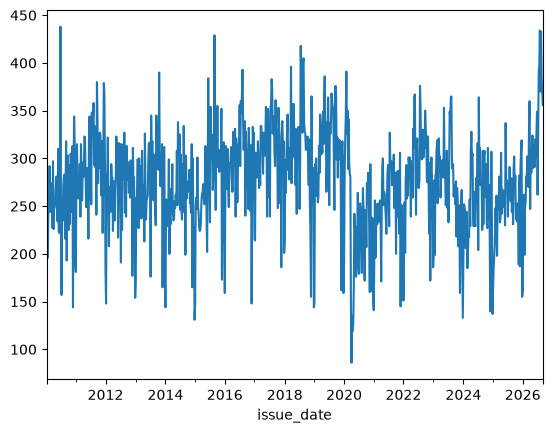

In [43]:
weekly.plot()

<Axes: xlabel='issue_date'>

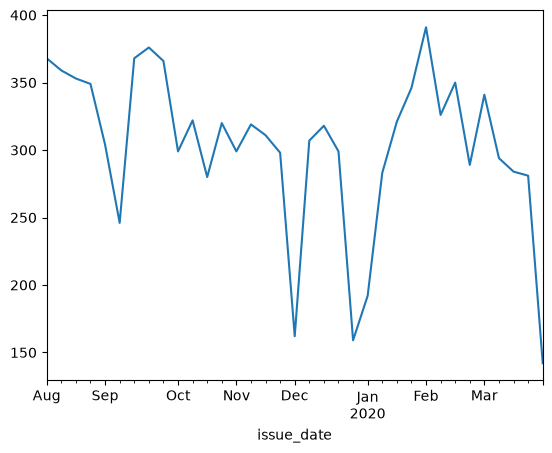

In [ ]:
weekly['2019-08':'2020-03'].plot()

In [ ]:
agg(
  total=('jobs', 'sum'),
  days=('days', 'size')
)

In [ ]:
weekly[weekly['days'] != 7]

In [ ]:
weekly = weekly[weekly['days'] == 7].drop(columns='days')

In [ ]:
full = pd.date_range(df.index.min(), df.index.max(), freq='D')

In [ ]:
whole_f = whole_f.reindex(full; fill_value=0)

In [ ]:
weekly.index = weekly.index - pd.Timedelta(days=6)

ValueError: func must be a callable if args or kwargs are supplied